In [233]:
import numpy as np

from TimeSeriesGenerator import EventFrequency, EventSampleSpace, TimeSeriesGenerator

In [234]:
N = 6
time_intervals = [(i, i+1) for i in range(N)]
occurrences = [i+1 for i in range(N)]
periods_sds = [0.05]*N
no_occurrences_sds = [0]*N

print("Time intervals:", time_intervals)
print("Occurrences:", occurrences)
print("Period standard deviations:", periods_sds)
print("Number of occurrences standard deviations:", no_occurrences_sds)

Time intervals: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]
Occurrences: [1, 2, 3, 4, 5, 6]
Period standard deviations: [0.05, 0.05, 0.05, 0.05, 0.05, 0.05]
Number of occurrences standard deviations: [0, 0, 0, 0, 0, 0]


In [235]:
class ExampleSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
    
    def sample(self, t):
        return np.random.normal(loc=1, scale=0)

In [236]:
EF = EventFrequency(occurrences, time_intervals, periods_sds, no_occurrences_sds)
ESS = ExampleSampleSpace()

In [237]:
def on_event(event):
    print(event)

time_series_generator = TimeSeriesGenerator([(EF, ESS)], on_event)
data, data_ideal, data_shifted, data_ideal_shifted = time_series_generator.run(N+1)
print("Generated data:", data)
print("Generated ideal data:", data_ideal)
print("Generated shifted data:", data_shifted)
print("Generated ideal shifted data:", data_ideal_shifted)

(0.9470549283999552, 1.0)
(2.0169504368099194, 1.0)
(2.303690014405304, 1.0)
(2.6933450587944114, 1.0)
(3.079917748436869, 1.0)
(3.2861422643788902, 1.0)
(3.5194066136310327, 1.0)
(3.755074092263009, 1.0)
(3.9220509867056728, 1.0)
(4.146813517092678, 1.0)
(4.3585310063169045, 1.0)
(4.481993447240269, 1.0)
(4.724720143069315, 1.0)
(4.979361653343305, 1.0)
(5.191342808353075, 1.0)
(5.3689006089070315, 1.0)
(5.538022295506826, 1.0)
(5.694295644910989, 1.0)
(6.007387192653647, 1.0)
(7.077235562603464, 1.0)
(7.498633012710841, 1.0)
Generated data: [(0.9470549283999552, 1.0), (2.0169504368099194, 1.0), (2.303690014405304, 1.0), (2.6933450587944114, 1.0), (3.079917748436869, 1.0), (3.2861422643788902, 1.0), (3.5194066136310327, 1.0), (3.755074092263009, 1.0), (3.9220509867056728, 1.0), (4.146813517092678, 1.0), (4.3585310063169045, 1.0), (4.481993447240269, 1.0), (4.724720143069315, 1.0), (4.979361653343305, 1.0), (5.191342808353075, 1.0), (5.3689006089070315, 1.0), (5.538022295506826, 1.0), 

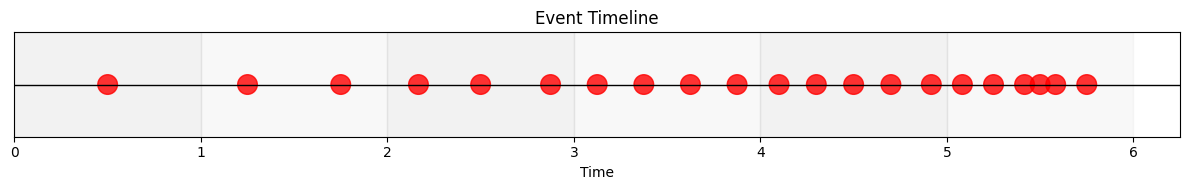

In [238]:
import matplotlib.pyplot as plt

# Assume `data` is a list of (time, scale) tuples,
# and `time_intervals` is a list of (start, end) tuples, already defined.

# Unpack times and scales
times, scales = zip(*data_ideal_shifted)

# All events sit on the same horizontal line
ys = [0] * len(times)

# Map scales to marker sizes (adjust the multiplier as needed)
marker_sizes = [s * 200 for s in scales]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 2))

# Draw baseline timeline
ax.hlines(0, min(times) - 0.5, max(times) + 0.5, color='black', linewidth=1)

# Shade each period for context
for idx, (start, end) in enumerate(time_intervals):
    alpha = 0.1 if idx % 2 == 0 else 0.05
    ax.axvspan(start, end, color='gray', alpha=alpha)

# Plot events as red circles
ax.scatter(times, ys, s=marker_sizes, color='red', alpha=0.8)

# Hide y-axis ticks and labels
ax.set_yticks([])

# Labels and title
ax.set_xlabel('Time')
ax.set_title('Event Timeline')

# Set plot limits
ax.set_xlim(min(times) - 0.5, max(times) + 0.5)
ax.set_ylim(-0.5, 0.5)

plt.tight_layout()
plt.show()


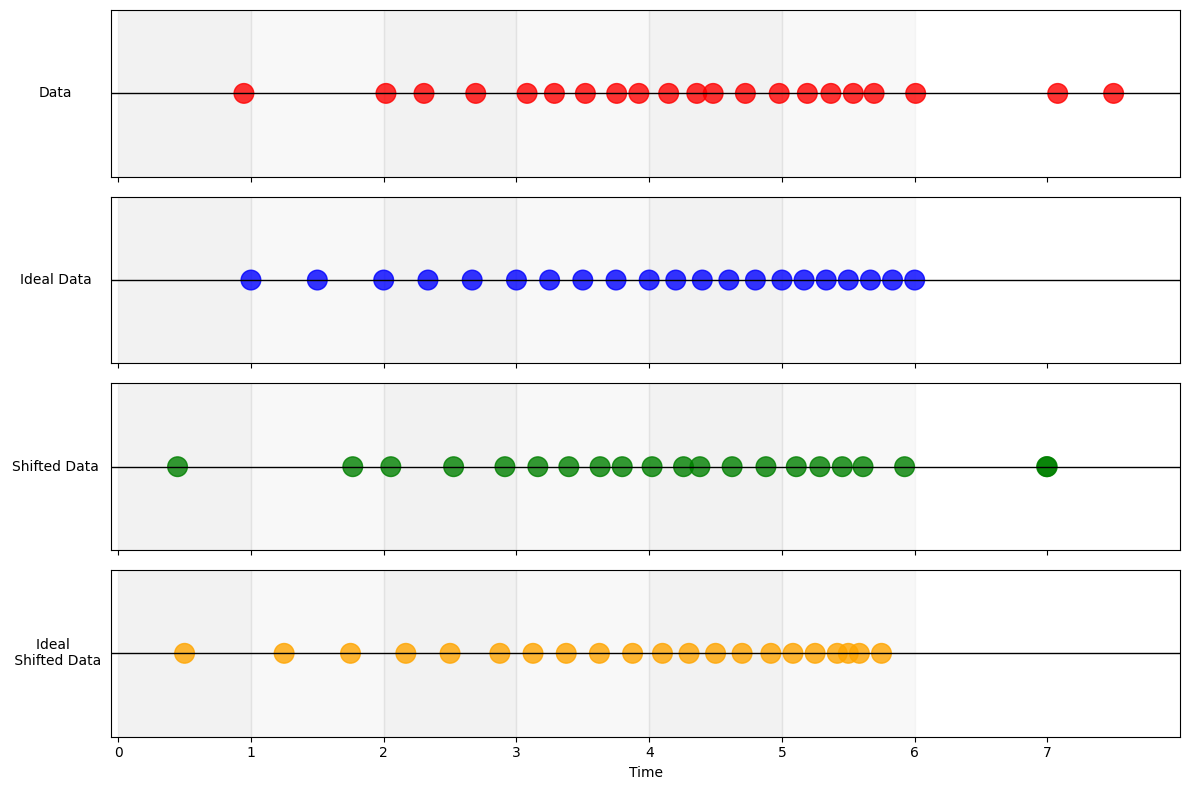

In [239]:
import matplotlib.pyplot as plt


def plot_multiple_timelines(data_list, time_intervals, titles, colors):
    """
    Plot multiple event timelines stacked vertically.

    Parameters:
    - data_list: List of data sources, each being a list of (time, scale) tuples.
    - time_intervals: List of (start, end) tuples defining shaded periods.
    - titles: List of titles for each subplot.
    - colors: List of colors for the markers of each subplot.

    Each timeline will be drawn on its own subplot, sharing the same x-axis.
    """
    n = len(data_list)
    if not (len(titles) == len(colors) == n):
        raise ValueError("data_list, titles and colors must have the same length")

    # Create subplots, one row per data source
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 2 * n), sharex=True)
    if n == 1:
        axes = [axes]

    # Determine global x-limits from all data
    all_times = [t for data in data_list for t, _ in data]
    xmin, xmax = min(all_times) - 0.5, max(all_times) + 0.5

    for i, (data, title, color) in enumerate(zip(data_list, titles, colors)):
        times, scales = zip(*data)
        ys = [0] * len(times)
        marker_sizes = [s * 200 for s in scales]

        ax = axes[i]
        # Draw baseline timeline
        ax.hlines(0, xmin, xmax, color='black', linewidth=1)

        # Shade each period for context
        for idx, (start, end) in enumerate(time_intervals):
            alpha = 0.1 if idx % 2 == 0 else 0.05
            ax.axvspan(start, end, color='gray', alpha=alpha)

        # Plot events
        ax.scatter(times, ys, s=marker_sizes, color=color, alpha=0.8)

        # Hide y-axis
        ax.set_yticks([])
        ax.set_ylabel(title, rotation=0, labelpad=40, va='center')

        # Only label x-axis on the bottom plot
        if i == n - 1:
            ax.set_xlabel('Time')

        # Set vertical limits to center the line
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(-0.5, 0.5)

    plt.tight_layout()
    plt.show()

data_list = [data, data_ideal, data_shifted, data_ideal_shifted]
titles = ['Data', 'Ideal Data', 'Shifted Data', 'Ideal \n Shifted Data']
colors = ['red', 'blue', 'green', 'orange']
plot_multiple_timelines(data_list, time_intervals, titles, colors)

In [240]:
from Analytics import count_number_of_occurrences_in_intervals
print(data)
count_number_of_occurrences_in_intervals(time_intervals, data_shifted)

[(0.9470549283999552, 1.0), (2.0169504368099194, 1.0), (2.303690014405304, 1.0), (2.6933450587944114, 1.0), (3.079917748436869, 1.0), (3.2861422643788902, 1.0), (3.5194066136310327, 1.0), (3.755074092263009, 1.0), (3.9220509867056728, 1.0), (4.146813517092678, 1.0), (4.3585310063169045, 1.0), (4.481993447240269, 1.0), (4.724720143069315, 1.0), (4.979361653343305, 1.0), (5.191342808353075, 1.0), (5.3689006089070315, 1.0), (5.538022295506826, 1.0), (5.694295644910989, 1.0), (6.007387192653647, 1.0), (7.077235562603464, 1.0), (7.498633012710841, 1.0)]


[1, 1, 3, 4, 5, 5]